Antal rækker i fil: 414
Antal rækker med run_result: 411

ALLE
  n              = 411
  middel         = 75.139
  sigma empirisk = 1040.495
  sigma teoretisk= 1000.000

UP
  n              = 143
  middel         = 265.301
  sigma empirisk = 947.769
  sigma teoretisk= 1000.000

DOWN
  n              = 132
  middel         = -33.621
  sigma empirisk = 999.120
  sigma teoretisk= 1000.000

NONE
  n              = 136
  middel         = -19.250
  sigma empirisk = 1147.012
  sigma teoretisk= 1000.000


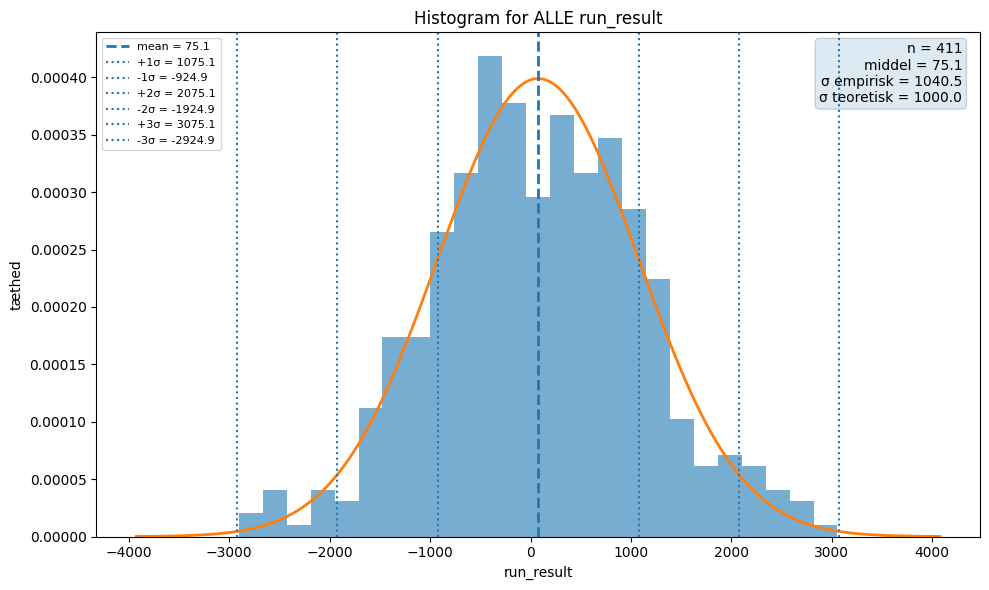

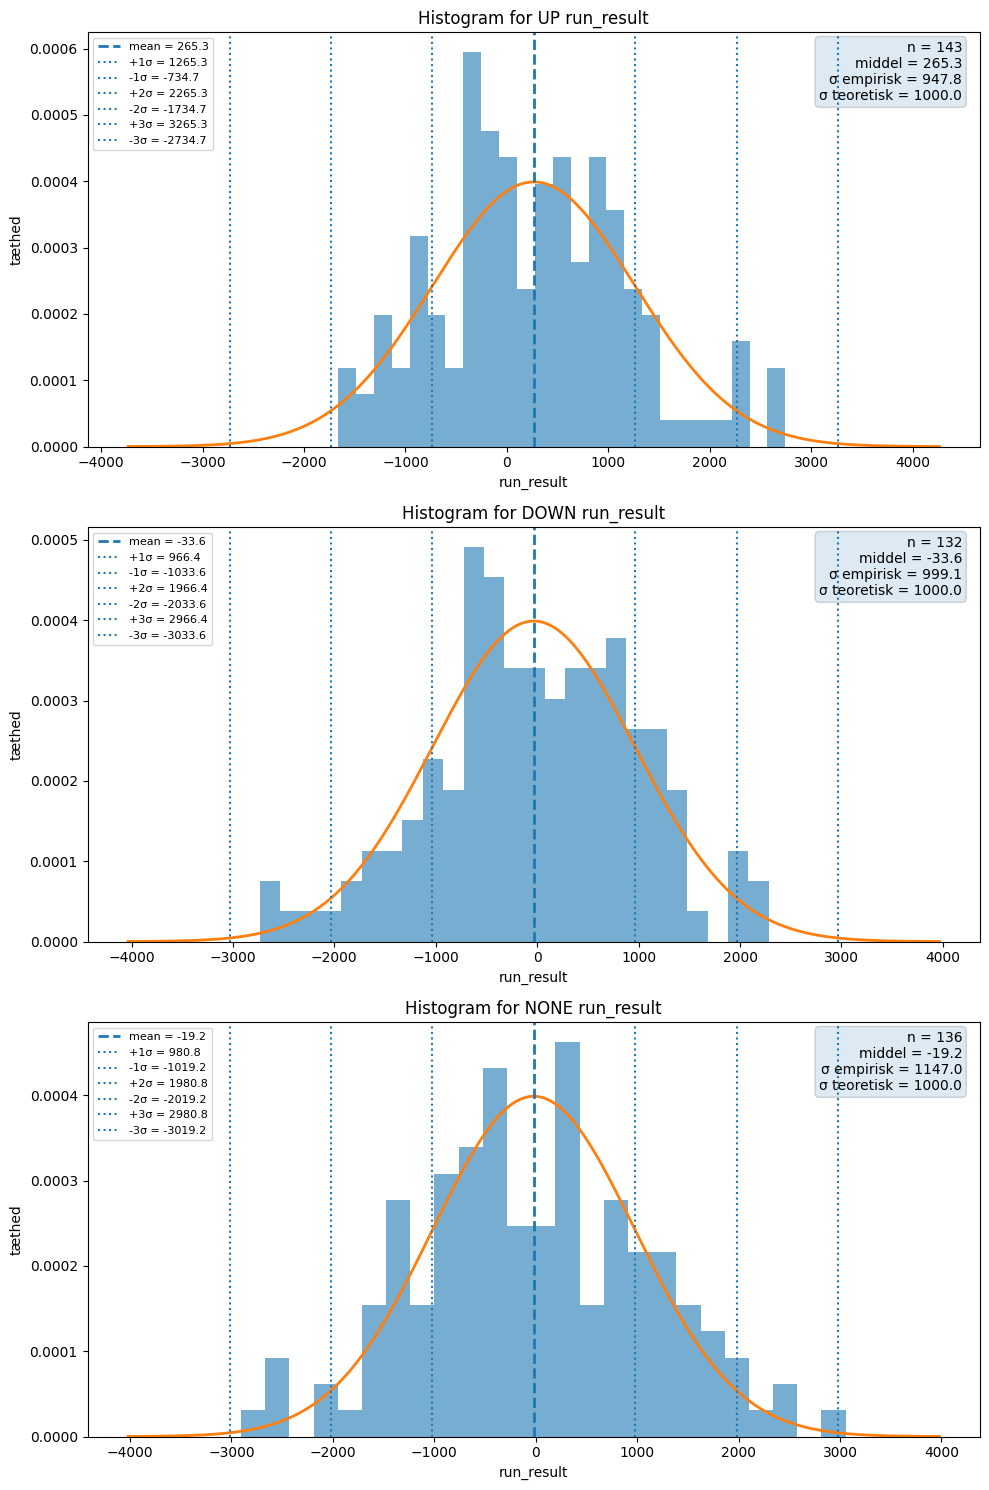

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INDSTILLINGER
# ============================================================

CSV_FILE = "accum_log-no_lowpass-LSB-von-neumann.csv"
BINS = 25
STEP_SIZE = 1.0   # Von Neumann output mappet til -1 / +1

# ============================================================
# HJÆLPEFUNKTIONER
# ============================================================

def normal_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def theoretical_sigma(bits, step_size=1.0):
    return step_size * np.sqrt(bits)

def add_sigma_lines(ax, mu, sigma):
    ax.axvline(mu, linestyle="--", linewidth=2, label=f"mean = {mu:.1f}")
    for k in [1, 2, 3]:
        ax.axvline(mu + k * sigma, linestyle=":", linewidth=1.5, label=f"+{k}σ = {mu + k*sigma:.1f}")
        ax.axvline(mu - k * sigma, linestyle=":", linewidth=1.5, label=f"-{k}σ = {mu - k*sigma:.1f}")

def get_group_bits(sub_df):
    """
    Finder den teoretiske bits-værdi til gruppen.
    Hvis alle rækker har samme bits, bruges den.
    Ellers bruges medianen som robust standardvalg.
    """
    if len(sub_df) == 0:
        return None

    bits_series = sub_df["bits"].dropna()
    if len(bits_series) == 0:
        return None

    if bits_series.nunique() == 1:
        return float(bits_series.iloc[0])

    return float(bits_series.median())

def plot_histogram(ax, sub_df, title):
    data = sub_df["run_result"].dropna().to_numpy()

    if len(data) == 0:
        ax.set_title(title + " (ingen data)")
        ax.axis("off")
        return

    mu_emp = np.mean(data)
    sigma_emp = np.std(data, ddof=1) if len(data) > 1 else 0.0

    bits_used = get_group_bits(sub_df)
    sigma_theory = theoretical_sigma(bits_used, STEP_SIZE) if bits_used is not None else np.nan

    # Brug teoretisk sigma til sigma-linjer og normal-kurve, hvis vi har den
    sigma_for_curve = sigma_theory if np.isfinite(sigma_theory) and sigma_theory > 0 else sigma_emp

    ax.hist(data, bins=BINS, density=True, alpha=0.6)

    if sigma_for_curve > 0:
        x_min = min(np.min(data), mu_emp - 4 * sigma_for_curve)
        x_max = max(np.max(data), mu_emp + 4 * sigma_for_curve)
        x = np.linspace(x_min, x_max, 800)
        y = normal_pdf(x, mu_emp, sigma_for_curve)
        ax.plot(x, y, linewidth=2)

    add_sigma_lines(ax, mu_emp, sigma_for_curve)

    ax.set_title(title)
    ax.set_xlabel("run_result")
    ax.set_ylabel("tæthed")

    if np.isfinite(sigma_theory):
        info = (
            f"n = {len(data)}\n"
            f"middel = {mu_emp:.1f}\n"
            f"σ empirisk = {sigma_emp:.1f}\n"
            f"σ teoretisk = {sigma_theory:.1f}"
        )
    else:
        info = (
            f"n = {len(data)}\n"
            f"middel = {mu_emp:.1f}\n"
            f"σ empirisk = {sigma_emp:.1f}\n"
            f"σ teoretisk = ukendt"
        )

    ax.text(
        0.98, 0.98, info,
        transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    ax.legend(fontsize=8)

# ============================================================
# INDLÆS FIL
# ============================================================

df = pd.read_csv(CSV_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

required_cols = {"timestamp", "mode", "direction", "total", "bits", "raw_samples"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Filen mangler disse kolonner: {missing}")

# ============================================================
# RUN-RESULTAT = DIFFERENS TIL FORRIGE AF SAMME TYPE
# ============================================================

df["run_result"] = df.groupby("direction")["total"].diff()

# Hvis du hellere vil gruppere på både mode og direction:
# df["run_result"] = df.groupby(["mode", "direction"])["total"].diff()

df_valid = df.dropna(subset=["run_result"]).copy()

# ============================================================
# PRINT STATISTIK
# ============================================================

print("Antal rækker i fil:", len(df))
print("Antal rækker med run_result:", len(df_valid))

for label, sub in [
    ("ALLE", df_valid),
    ("UP", df_valid[df_valid["direction"] == "UP"]),
    ("DOWN", df_valid[df_valid["direction"] == "DOWN"]),
    ("NONE", df_valid[df_valid["direction"] == "NONE"]),
]:
    if len(sub) == 0:
        continue

    sigma_emp = np.std(sub["run_result"], ddof=1) if len(sub) > 1 else np.nan
    bits_used = get_group_bits(sub)
    sigma_theory = theoretical_sigma(bits_used, STEP_SIZE) if bits_used is not None else np.nan

    print(f"\n{label}")
    print(f"  n              = {len(sub)}")
    print(f"  middel         = {sub['run_result'].mean():.3f}")
    print(f"  sigma empirisk = {sigma_emp:.3f}")
    print(f"  sigma teoretisk= {sigma_theory:.3f}" if np.isfinite(sigma_theory) else "  sigma teoretisk= ukendt")

# ============================================================
# FIGUR 1: ALLE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
plot_histogram(ax, df_valid, "Histogram for ALLE run_result")
plt.tight_layout()
plt.show()

# ============================================================
# FIGUR 2: UP / DOWN / NONE
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for ax, direction in zip(axes, ["UP", "DOWN", "NONE"]):
    sub = df_valid[df_valid["direction"] == direction]
    plot_histogram(ax, sub, f"Histogram for {direction} run_result")

plt.tight_layout()
plt.show()